In [82]:
import numpy as np
from numpy.typing import NDArray
from typing import Callable,Tuple,List
import matplotlib.pyplot as plt
from nb1_droplet_utils import *


In [ ]:
class Geometry():
    def __init__(self,BASE_NX,BASE_NY,L) -> None:
        self.BASE_NX = BASE_NX
        self.BASE_NY = BASE_NY
        
        self.Nx = L*BASE_NX
        self.Ny = L*BASE_NY

class DataManager():
    def __init__(self,id,geometry:Geometry) -> None:

        self.id = id
        is_occupied  = np.full((geometry.Ny,geometry.Nx),fill_value=-1,dtype=np.int16)
        chemA = np.full((geometry.Ny,geometry.Nx),fill_value=0.0,dtype=np.float32)
        chemB = np.full((geometry.Ny,geometry.Nx),fill_value=0.0,dtype=np.float32)
        collisions:List[Tuple[int,int]] = []
        
    def write_data(self):
        pass


In [ ]:
class Particle:
    def __init__(self,i,x,y,
                theta,radius) -> None:
        self.id = i
        # wrapped (for simulation)
        self.x = x
        self.y = y
        
        # unwrapped (for tracking)
        self.x_unwrapped = x
        self.y_unwrapped = y
        
        self.theta = theta
        self.radius = radius
        self.v = 5.0

def populate_is_occupied(radius,xc,yc,id,is_occupied: NDArray,
                        collisions:List[Tuple[int,int]]):
    Ny,Nx = is_occupied.shape
    
    xa = max(0,int(xc-radius))
    xb = min(Nx , int(xc+radius)+1)
    ya = max(0,int(yc-radius))
    yb = min(Ny , int(yc+radius)+1)
    
    for x in range(xa,xb):
        for y in range(ya,yb):    
            if (x-xc)**2 + (y-yc)**2 <= radius*radius:
                xp = x % Nx
                yp = y % Ny
                if is_occupied[yp,xp] == -1:
                    is_occupied[yp,xp] = id
                else:
                    # so we will define some function like 
                    # def collision
                    collisions.append((id,is_occupied[yp,xp]))



def move(particle:Particle,Nx:int,Ny:int,
        chemA:NDArray,chemB: NDArray)->None:
    
    
    
    # compute displacement
    dx = particle.v * np.cos(particle.theta)
    dy = particle.v * np.sin(particle.theta)
    
    # update wrapped position (for simulation)
    particle.x = (particle.x + dx) % Nx
    particle.y = (particle.y + dy) % Ny
    
    # update unwrapped position (NO modulo!)
    particle.x_unwrapped += dx
    particle.y_unwrapped += dy
    


# def move(particle:Particle,Nx:int,Ny:int)->None:
    
#     # compute displacement
#     dx = particle.v * np.cos(particle.theta)
#     dy = particle.v * np.sin(particle.theta)
    
#     # update wrapped position (for simulation)
#     particle.x = (particle.x + dx) % Nx
#     particle.y = (particle.y + dy) % Ny
    
#     # update unwrapped position (NO modulo!)
#     particle.x_unwrapped += dx
#     particle.y_unwrapped += dy
    
    
def deposit_chemB(particles: List[Particle],chemB: NDArray,strength : float = 1.0):
    
    Ny,Nx = chemB.shape
    for particle in particles:
        xc = particle.x 
        yc = particle.y
        r = particle.radius
        
        xa = int(xc-r)
        xb = int(xc+r)+1
        ya = int(yc-r)
        yb = int(yc+r)+1
    
        for x in range(xa,xb):
            for y in range(ya,yb):
                if (x-xc)**2 + (y-yc)**2 <= r*r:
                    xp = x%Nx
                    yp = y%Ny
        
                    chemB[yp,xp] = 1+0.3*np.random.randn()
            
    
def laplacian(field:NDArray)-> NDArray:
    lap_field = np.full(shape=field.shape,fill_value=np.nan)
    Ny,Nx = field.shape
    
    for x in range(Nx):
        for y in range(Ny):
            
            term = (field[(y+1)%Ny,x] + field[(y-1)%Ny,x] +
                    field[y,(x+1)%Nx] + field[y,(x-1)%Nx] -
                    4 * field[y,x])
            lap_field[y,x] = term
            
    return lap_field
    
def gradient(field: NDArray) -> Tuple[NDArray, NDArray]:
    Ny, Nx = field.shape
    
    grad_x = np.full(field.shape, np.nan)
    grad_y = np.full(field.shape, np.nan)
    
    for x in range(Nx):
        for y in range(Ny):
            
            grad_x[y, x] = (
                field[y, (x+1)%Nx] - field[y, (x-1)%Nx]
            ) * 0.5
            
            grad_y[y, x] = (
                field[(y+1)%Ny, x] - field[(y-1)%Ny, x]
            ) * 0.5
    
    return grad_x, grad_y

def gradient_normalized(field: NDArray) -> Tuple[NDArray, NDArray]:
    Ny, Nx = field.shape
    
    grad_x = np.full(field.shape, np.nan)
    grad_y = np.full(field.shape, np.nan)
    
    for x in range(Nx):
        for y in range(Ny):
            
            dcdx =  (
                field[y, (x+1)%Nx] - field[y, (x-1)%Nx]
            ) * 0.5
            
            dcdy = (
                field[(y+1)%Ny, x] - field[(y-1)%Ny, x]
            ) * 0.5
    
            mag_grad = np.sqrt(dcdx*dcdx + dcdy*dcdy)
            mag_grad = np.max((mag_grad,1e-5))
            
            grad_x[y, x] = dcdx/mag_grad            
            grad_y[y, x] = dcdy/mag_grad
    
    return grad_x, grad_y


In [156]:
L = 10
BASE_NX = 100
BASE_NY = 100 
Nx = L*BASE_NX
Ny = L*BASE_NY


is_occupied  = np.full((Ny,Nx),fill_value=-1,dtype=np.int16)
chemA = np.full((Ny,Nx),fill_value=0.0,dtype=np.float32)
chemB = np.full((Ny,Nx),fill_value=0.0,dtype=np.float32)


In [85]:
import numpy as np

def gaus2d_pdf(x, y, mx, my, sx, sy):
    """
    Calculates the 2D Gaussian probability density function value at a given point.
    """
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

# Create a grid of coordinates
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y) # Creates 2D variables from 1D arrays

# Example usage with center (mx, my) = (0, 0) and spreads (sx, sy) = (1, 1)
z = gaus2d_pdf(X, Y, mx=0, my=0, sx=1, sy=1)


In [ ]:
particles = []
collisions = []
num_particles = 6
for i in range(1,num_particles+1):
    x =  Nx *np.random.rand()
    y =  Nx *np.random.rand()
    theta = 2*np.pi* np.random.rand()
    radius = 20.0 + 5.*np.random.rand()
    particles.append(Particle(i,x,y,theta,radius))
    
for p in particles:
    print(p.x, p.y)


181.5134057845673 455.4892661783848
701.6054348876924 712.1117736725827
333.704441997441 90.13896378675979
846.8798107354326 940.3989946017626
176.11254754666695 178.9452807964773
53.272393924598035 150.97409665390094


In [138]:
# deposit_chemB(particles=particles,chemB=chemB)


In [ ]:
def init_gaussian(chemB, x0, y0, sigma=10.0, amplitude=1.0):
    Ny, Nx = chemB.shape
    
    for y in range(Ny):
        for x in range(Nx):
            dx = x - x0
            dy = y - y0
            
            chemB[y, x] += amplitude * np.exp(
                -(dx*dx + dy*dy) / (2*sigma*sigma))

chemB.fill(0.0)

for particle in particles:
    init_gaussian(chemB, particle.x, particle.y,sigma=20.0,amplitude=10.0)
chemB.min(),chemB.max()


(np.float32(0.0), np.float32(10.001414))

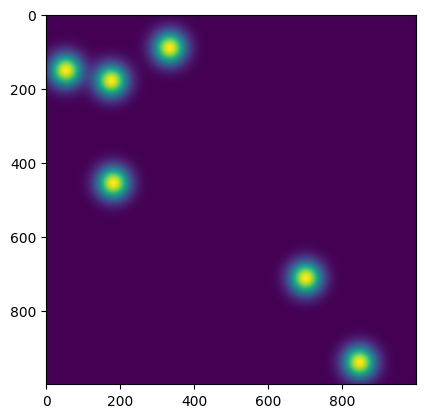

In [148]:
plt.imshow(chemB)


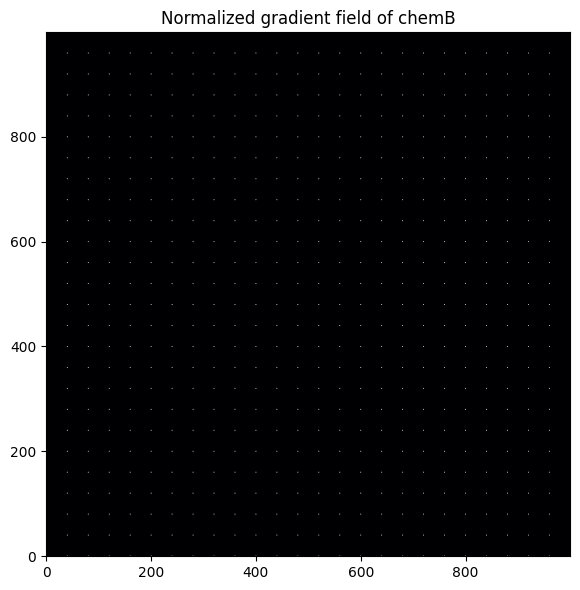

In [167]:
chemA = np.full((Ny,Nx),fill_value=0.0,dtype=np.float32)

def init_chemA_linear(chemA):
    Ny, Nx = chemA.shape
    
    for y in range(Ny):
        for x in range(Nx):
            chemA[y, x] = 100* (x / Nx)

dcdx,dcdy = gradient(chemA)
skip = 40
Y, X = np.mgrid[:Ny, :Nx]

plt.figure(figsize=(6, 6))
plt.imshow(chemA, cmap="inferno", origin="lower")
plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    dcdx[::skip, ::skip],
    dcdy[::skip, ::skip],
    color="white",
    pivot="mid",
    scale=25,
    width=0.002,
)
plt.title("Normalized gradient field of chemB")
# plt.xlim(0,250)
# plt.ylim(100,300)

plt.tight_layout()
plt.show()


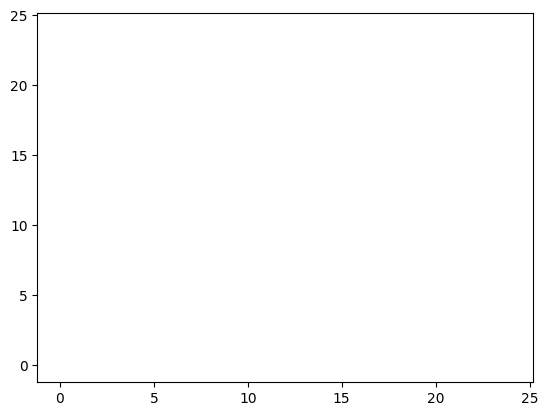

In [166]:
dcdx,dcdy = gradient_normalized(chemA)
plt.quiver(dcdx[::40,::40],dcdy[::40,::40])


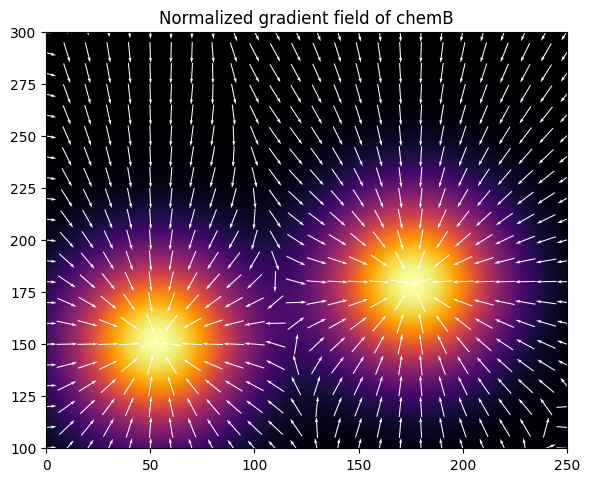

In [153]:
skip = 10
Y, X = np.mgrid[:Ny, :Nx]

plt.figure(figsize=(6, 6))
plt.imshow(chemB, cmap="inferno", origin="lower")
plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    dcdx[::skip, ::skip],
    dcdy[::skip, ::skip],
    color="white",
    pivot="mid",
    scale=25,
    width=0.002,
)
plt.title("Normalized gradient field of chemB")
plt.xlim(0,250)
plt.ylim(100,300)

plt.tight_layout()
plt.show()


In [92]:
num_steps = 1000
num_particles = 4
positions = np.zeros((num_steps, num_particles, 2))


In [93]:

for i in range(num_steps):
    is_occupied.fill(-1)
    collisions.clear()

    for particle in particles:
        populate_is_occupied(radius=particle.radius,xc=particle.x,yc=particle.y,
                            id=particle.id,is_occupied=is_occupied,collisions=collisions)
        
    for particle in particles:
        move(particle=particle,Nx=Nx,Ny=Ny)
        positions[i,particle.id-1,0] = particle.x_unwrapped
        positions[i,particle.id-1,1] = particle.y_unwrapped
        

In [94]:
# to get positions 
positions[:,2,:].shape


(1000, 2)

In [95]:
particles # pairs 4*3/2
inter_distance = list()
for i in range(num_particles):
    xi = particles[i].x
    yi = particles[i].y
    
    for j in range(i+1,num_particles):
        xj = particles[j].x
        yj = particles[j].y
        
        dx = xi - xj
        dy = yi - yj
        
        # periodic correction
        dx -= Nx * np.round(dx / Nx)
        dy -= Ny * np.round(dy / Ny)
        
        dij = np.sqrt(dx*dx + dy*dy)
        
        inter_distance.append((i, j, dij))
    

inter_distance
    

[(0, 1, np.float64(322.11123039297263)),
 (0, 2, np.float64(501.2170654521751)),
 (0, 3, np.float64(286.4878562938294)),
 (1, 2, np.float64(363.3145477488481)),
 (1, 3, np.float64(479.1381069928419)),
 (2, 3, np.float64(216.6312026718173))]

In [ ]:
def local_field_avg(chem, R, dx=1.0):
    Ny, Nx = chem.shape
    avg_chem = np.zeros_like(chem, dtype=float)

    r_grid = int(R / dx)

    for i in range(Ny):
        for j in range(Nx):

            csum = 0.0
            count = 0

            # loop over neighborhood
            for di in range(-r_grid, r_grid + 1):
                for dj in range(-r_grid, r_grid + 1):

                    # circular cutoff
                    if (di*dx)**2 + (dj*dx)**2 <= R*R:

                        ni = (i + di) % Ny   # periodic
                        nj = (j + dj) % Nx

                        csum += chem[ni, nj]
                        count += 1

            avg_chem[i, j] = csum / count if count > 0 else 0.0

    return avg_chem
        
        
                

    
def update_theta(particles, chemA, chemB, chi=1.0):

    Ny, Nx = chemA.shape

    # --- build smoothed fields ---
    avg_chemA = local_field_avg(chemA, R=10)
    avg_chemB = local_field_avg(chemB, R=10)

    # --- gradients ---
    dAdx, dAdy = gradient(avg_chemA)
    dBdx, dBdy = gradient(avg_chemB)

    # --- update particles ---
    for particle in particles:

        i = int(particle.y) % Ny
        j = int(particle.x) % Nx

        # force = grad A - grad B
        fx = dAdx[i, j] - dBdx[i, j]
        fy = dAdy[i, j] - dBdy[i, j]

        # handle zero gradient
        if fx == 0 and fy == 0:
            fx = 1.0
            continue

        theta_f = np.arctan2(fy, fx)

        particle.theta += chi * np.sin(theta_f - particle.theta)


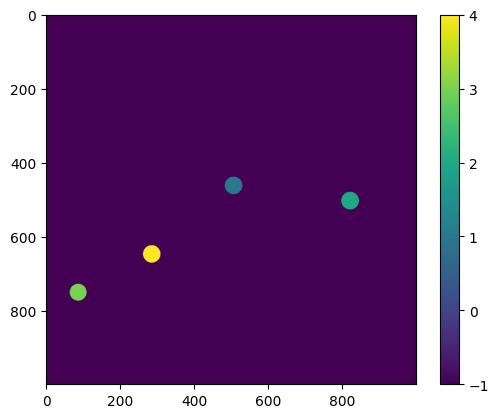

In [ ]:
plt.imshow(is_occupied)
plt.colorbar()


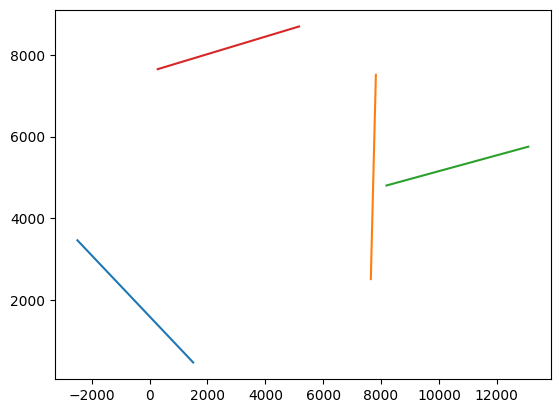

In [97]:
for i in range(num_particles):
    plt.plot(positions[:,i,0],positions[:,i,1])


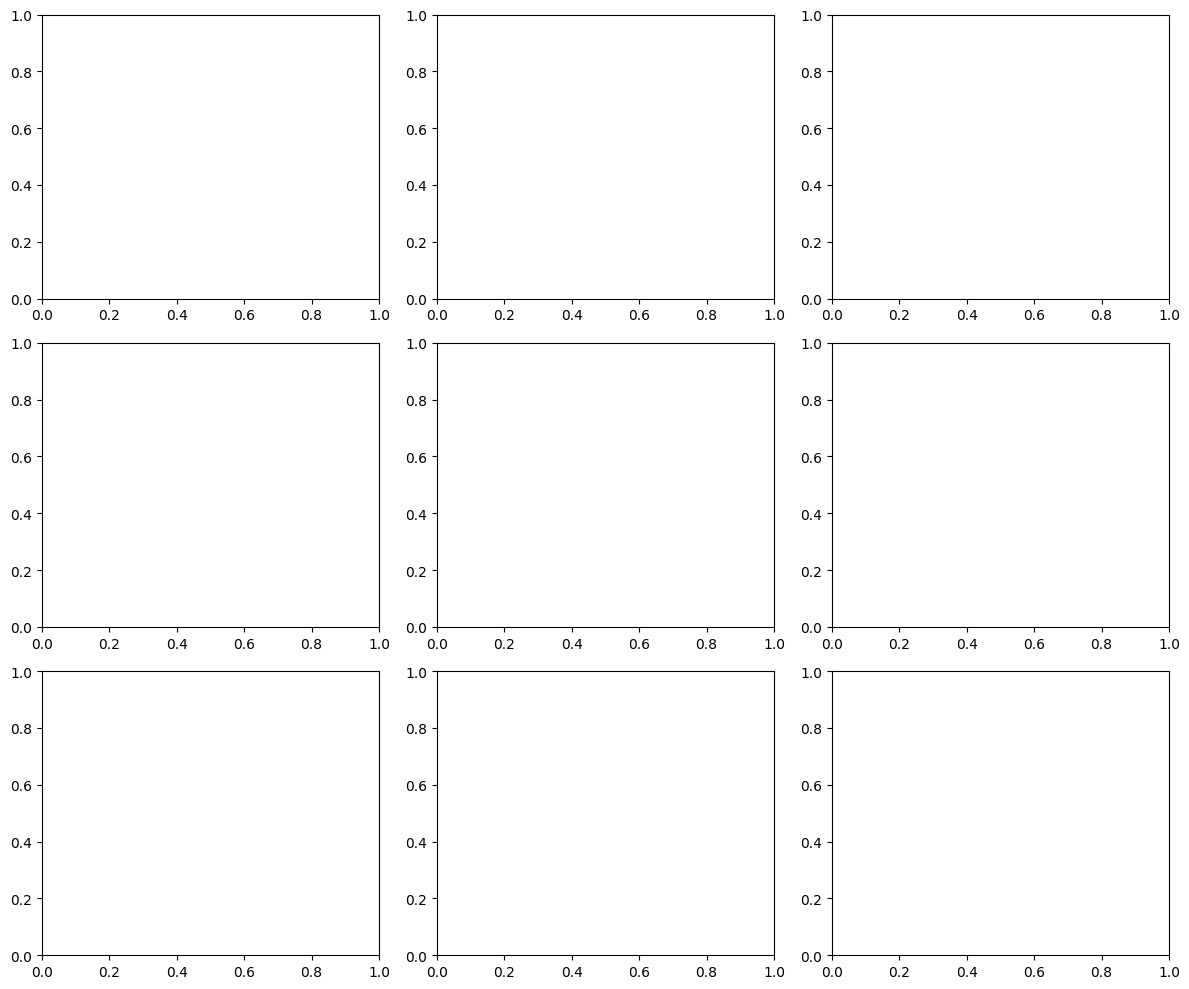

In [98]:
fig,ax = plt.subplots(3,3)
ax= ax.flatten()
fig.set_size_inches(12,10)

for i in range(1,901):
    is_occupied.fill(-1)
    collisions.clear()

    for particle in particles:
        populate_is_occupied(radius=particle.radius,xc=particle.x,yc=particle.y,
                            id=particle.id,is_occupied=is_occupied,collisions=collisions)
        
    for particle in particles:
        move(particle=particle,Nx=Nx,Ny=Ny)
        
        
    if len(collisions)!=0:
        # print(collisions)
        pass
    # if i%100 == 0:
    #     print(int(i/100))
    #     ax[int(i/100)-1].set_title(f'for t = {i}')
    #     ax[int(i/100)-1].imshow(is_occupied)
fig.tight_layout()


In [99]:
collisions


[]

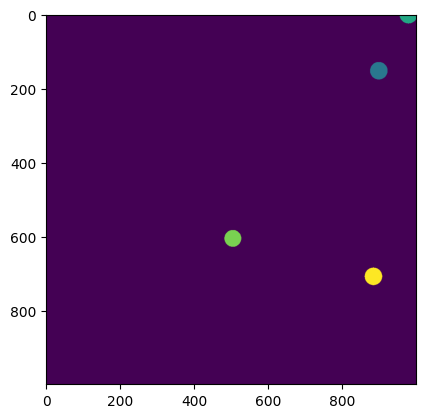

In [100]:
plt.imshow(is_occupied)


In [101]:
# def populate_is_occupied(radius,xc,yc,id,is_occupied: NDArray):
#     Nx,Ny = is_occupied.shape
#     for x in range(Nx):
#         for y in range(Ny):
#             if (x-xc)**2 + (y-yc)**2 <= radius*radius:
#                 is_occupied[y,x] = id
    


In [102]:
populate_is_occupied(radius=5.2,xc=10,yc=20,id=1,is_occupied=is_occupied)
populate_is_occupied(radius=5.2,xc=26,yc=20,id=4,is_occupied=is_occupied)
plt.imshow(is_occupied)


TypeError: populate_is_occupied() missing 1 required positional argument: 'collisions'

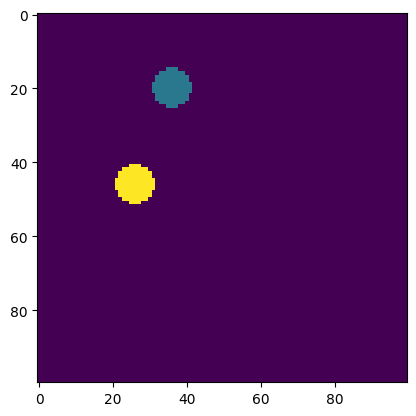

In [ ]:

for i in range(1,30,5):
    is_occupied.fill(-1)
    populate_is_occupied(radius=5.2,xc=10+i,yc=20,id=1,is_occupied=is_occupied)
    populate_is_occupied(radius=5.2,xc=26,yc=20+i,id=4,is_occupied=is_occupied)

plt.imshow(is_occupied)


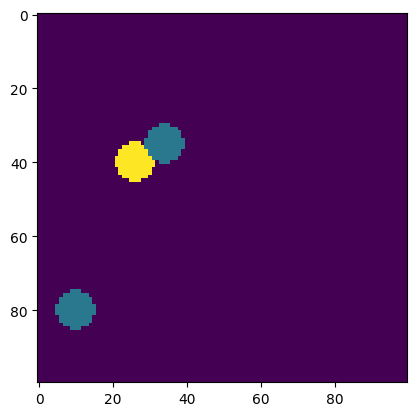

In [ ]:
populate_is_occupied(radius=5.2,xc=26+8,yc=40-5,id=1,is_occupied=is_occupied)
plt.imshow(is_occupied)


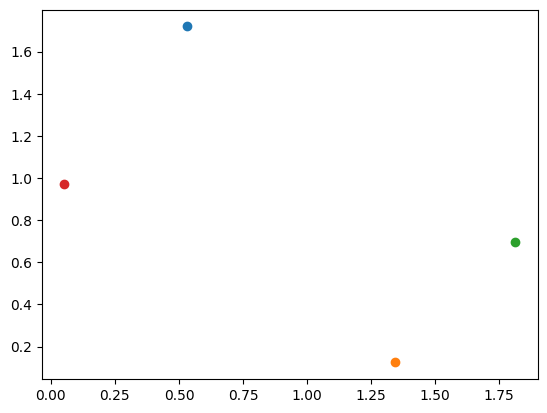

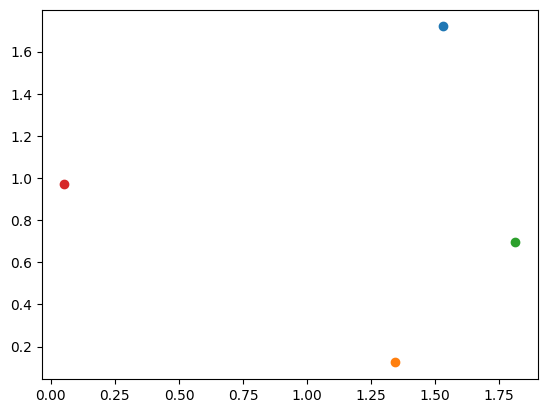

In [ ]:
particles = []
for i in range(4):
    x = L *np.random.rand()
    y = L *np.random.rand()
    theta = np.pi* np.random.rand()
    radius = 1.0 + 0.05*np.random.rand()
    particles.append(Particle(x,y,theta,radius))
    
for particle in particles:
    plt.scatter(particle.x,particle.y)
plt.show()

particles[0].x += 1.0

for particle in particles:
    plt.scatter(particle.x,particle.y)
    
    
    
    